<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE-NO-SUPERVISADO/blob/main/Clase_4_k_means_Mario_Guerrero_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clusterización

Se tiene un conjunto de datos para el cual se quiere un número de grupos a determinar por el analista y que estén conformados de manera que los clientes tengan características de consumo lo más parecidas posibles. Para ello se ha determinado que las variables más representativas para crear estos grupos son el gasto en dolares correspondiente a seis categorías: vino, frutas, carne, pescado, dulces y oro.

**Conexión con drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Cargue del archivo**

In [ ]:
import pandas as pd
path= '/content/drive/MyDrive/APREN. NO SUPERVISADO/marketing_campaign1.csv'
df= pd.read_csv(path, sep="\t")

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Subset

Se debe hacer una subconjunto que se utilizarán para el clustering, en este caso los datos del gasto en dolares para cada una de las categorias: wines, fruits, mean, fish, sweet, gold.

## Forma 1 de crear el subconjunto de datos
Usando el nombre de las columnas

In [ ]:
df.columns # Para conocer el nombre de las columnas

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
df_cat= df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]



In [ ]:
df_cat.head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15


## Forma 2 de crear el subconjunto de datos
Usando el número de las columnas

In [ ]:
data=df.iloc[:, 10:16] #datos para clustering
data.head()

,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases
0,88,546,172,88,88,3
1,1,6,2,1,6,2
2,49,127,111,21,42,1
3,4,20,10,3,5,2
4,43,118,46,27,15,5


##Instalación de librerías

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Exploración preliminar de las variables

Matriz de correlaciones

In [ ]:
corr_matrix = df_cat.corr()
corr_matrix

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
MntWines,1.000000,0.389637,0.562667,0.399753,0.386581,0.387516
MntFruits,0.389637,1.000000,0.543105,0.594804,0.567164,0.392995
MntMeatProducts,0.562667,0.543105,1.000000,0.568402,0.523846,0.350609
MntFishProducts,0.399753,0.594804,0.568402,1.000000,0.579870,0.422875
MntSweetProducts,0.386581,0.567164,0.523846,0.579870,1.000000,0.369724
MntGoldProds,0.387516,0.392995,0.350609,0.422875,0.369724,1.000000


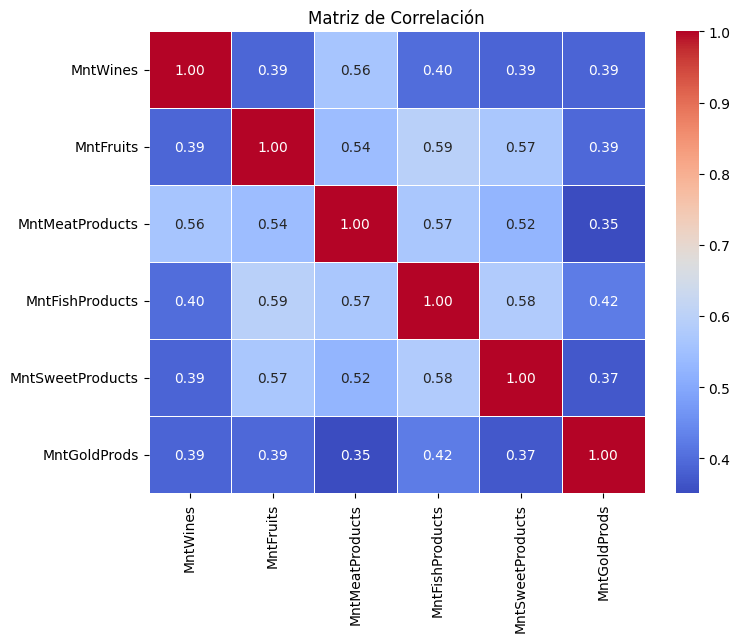

In [ ]:
plt.figure(figsize=(8,6))  # Ajusta el tamaño del gráfico
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

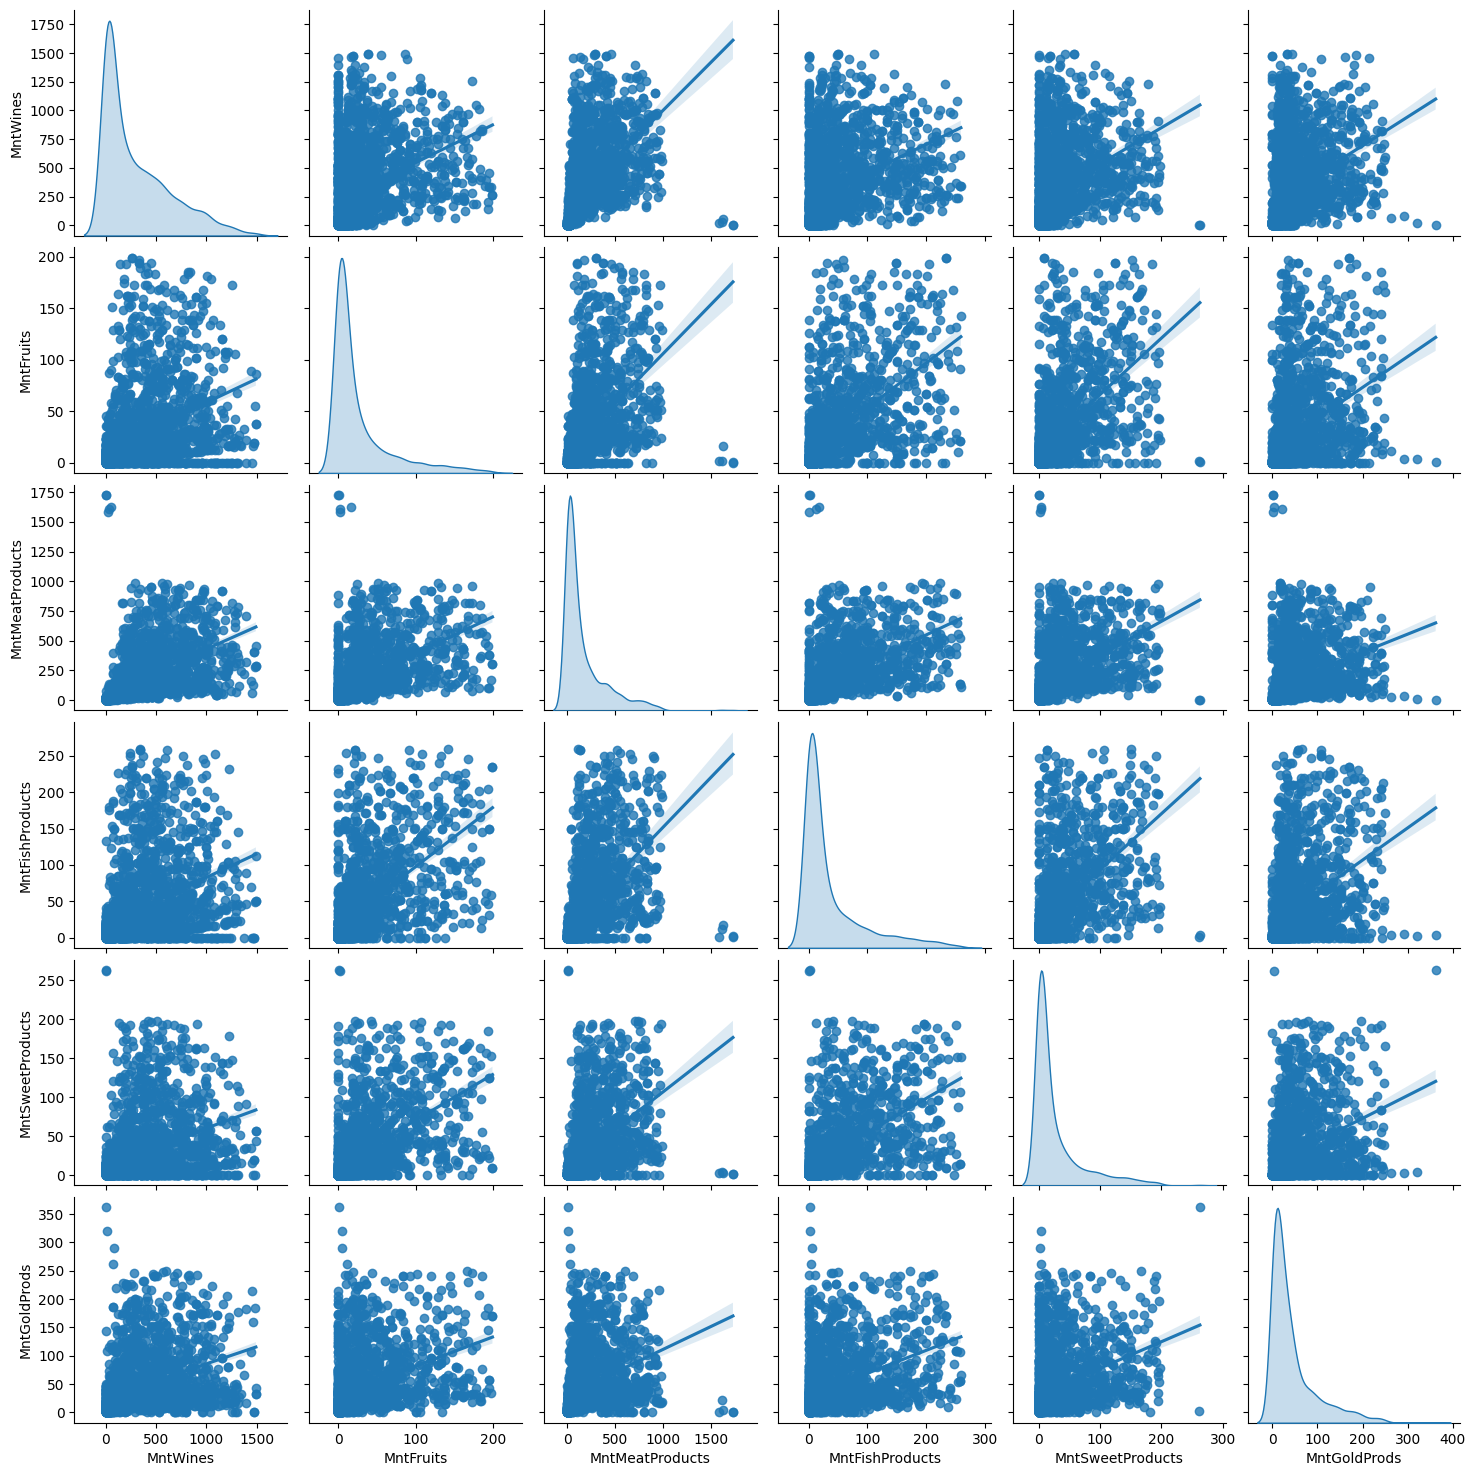

In [ ]:
sns.pairplot(df_cat, kind="reg", diag_kind="kde")
plt.show()


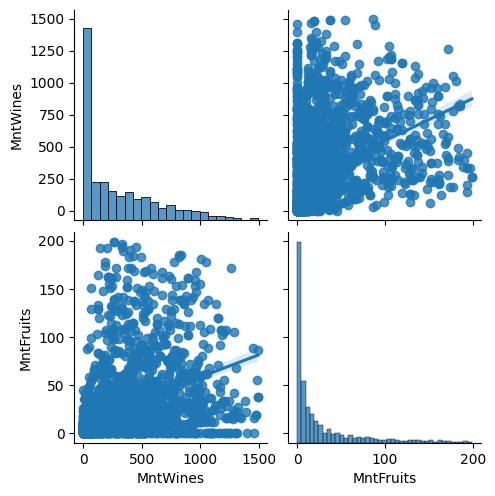

In [ ]:
sns.pairplot(df_cat[['MntWines','MntFruits']], kind="reg")
plt.show()

## Estandarización de variables

La estandarización de variables es un proceso de transformación en el que se ajustan los valores de una variable para que tengan una media de 0 y una desviación estándar de 1.

## Fórmula de la estandarización

Cada valor de la variable x se transforma así:
Z=(x−μ)/σ


Donde:

    Z = Valor estandarizado
    x = Valor original
    μ = Media de la variable
    σ = Desviación estándar de la variable

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cat)
scaled_features

array([[ 0.98378127,  1.55157698,  1.67970233,  2.46214705,  1.4765001 ,
         0.84320691],
       [-0.87047948, -0.63630116, -0.71322541, -0.65044925, -0.63150318,
        -0.72900579],
       [ 0.36272278,  0.57080402, -0.17703234,  1.34527426, -0.14690472,
        -0.03876607],
       ...,
       [ 1.79502034,  0.545656  ,  0.22178895, -0.10116755, -0.36497403,
        -0.38388593],
       [ 0.36866592,  0.09299156,  0.20849491,  0.77768317,  0.07116458,
         0.32552712],
       [-0.65355475, -0.58600511, -0.46950129, -0.65044925, -0.63150318,
        -0.4414059 ]])

In [ ]:
est=pd.DataFrame(scaled_features, columns=df_cat.columns)
est

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207
1,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006
2,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766
3,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179
4,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446
...,...,...,...,...,...,...
2235,1.203678,0.419916,0.066692,0.081926,2.203398,3.891766
2236,0.303291,-0.661449,-0.606873,-0.687068,-0.655733,-0.690659
2237,1.795020,0.545656,0.221789,-0.101168,-0.364974,-0.383886
2238,0.368666,0.092992,0.208495,0.777683,0.071165,0.325527


# Kmeans

Se crea crea el modelo de kmeans

In [ ]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=3, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

Ajuste del modelo

In [ ]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=3, n_init=10, random_state=42)

In [ ]:
kmeans.inertia_ # es la medida de la suma de las distancias al cuadrado entre cada punto y el centroide.
# Entre menor sea este valor, generalmente indica una mejor clusterización.
# Pero esta no debería ser la medida que determina el número de clusters.

6318.427062664645

In [ ]:
kmeans.cluster_centers_ # Muestra los centroides de los clusters

array([[-0.61908361, -0.5003944 , -0.58326963, -0.52166902, -0.50138979,
        -0.48639229],
       [ 0.64041779,  1.5888154 ,  1.20150635,  1.63535737,  1.66514736,
         0.88281773],
       [ 1.02390537,  0.13750133,  0.5793242 ,  0.15688142,  0.09063429,
         0.55984891]])

Los centroides estan estandarizados por lo tanto los queremos en su formato original

In [ ]:
df['hijos']= df['Kidhome']+df['Teenhome']

In [ ]:
df_con_hijos= df[df['hijos']> 0]
df_sin_hijos = df[df['hijos']== 0]

media_wines_con_hijos = df_con_hijos['MntWines'].mean()
media_wines_sin_hijos = df_sin_hijos['MntWines'].mean()

In [ ]:
media_wines_con_hijos
media_wines_sin_hijos

np.float64(487.30564263322884)

In [ ]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[ 95.60030511,   6.40427155,  35.32646834,   9.03356217,
          6.36994661,  18.65369947],
       [519.45054945,  89.48076923, 438.08791209, 126.84340659,
         95.78571429,  90.06593407],
       [648.50265487,  31.7699115 , 297.68318584,  46.09380531,
         30.80353982,  73.22123894]])

Ya tenemos un modelo que nos crea un número determinado de clusters. Ahora necesitamos saber cada registro en que cluster quedó asignado

In [ ]:
labels = kmeans.predict(scaled_features)
df['cluster'] = labels
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,hijos,cluster
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,2,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,0,2
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,1,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,0,3,11,0,1,1
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,1,0,0,3,11,0,3,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,1,0,0,0,0,3,11,0,0,2
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,0,0,0,0,0,3,11,0,1,2


## Número de clusters a crear

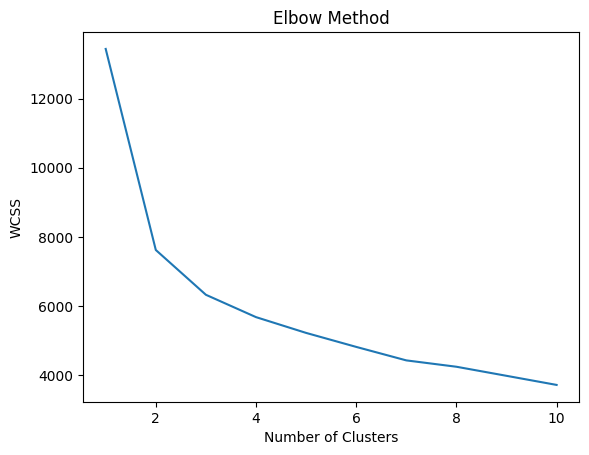

In [ ]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



---



## **COMO PREDECIR CON DATOS NUEVOS**

In [ ]:
import joblib # Esta librería sirve para guardar y llamar objetos de Python, como los modelos de machine learning
joblib.dump(kmeans, 'kmeans_model.pkl') # Se guarda el modelo de kmeans en el objeto 'kmeans_model.pkl'
joblib.dump(scaler, 'scaler.pkl') # Se guardan los parametros con los que se estandarizaron los datos con los que se entreno el modelo de kmeans

['scaler.pkl']

## Cuando se tiene solo una nueva observación

In [ ]:
kmeans = joblib.load('kmeans_model.pkl') # Se carga el modelo guardado en el objeto 'kmeans_model.pkl'
scaler = joblib.load('scaler.pkl') # Se carga el objeto 'scaler.pkl' con que se estandarizaron los datos del modelo


nueva_obs = np.array([[520,90,440,130,100,90]]) # Estos son los datos de la nueva observación que se quiere predecir a que cluster corresponde

nueva_obs_est = scaler.transform(nueva_obs) # Se estandariza la nueva observación

cluster = kmeans.predict(nueva_obs_est) # Se predice el cluster de la nueva observación

print(f"La nueva observación pertenece al cluster: {cluster[0]}")



La nueva observación pertenece al cluster: 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Cuando se tienen varias observaciones nuevas

In [ ]:
df_new = df.sample(n=50, random_state=42) # Vamos a tomar una muestra de 50 observaciones

df_new= df_new[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]

In [ ]:
nuevos_datos = scaler.transform(df_new) # Se estandarizan las nuevas observaciones

cluster = kmeans.predict(nuevos_datos) # Se predice el cluster de las nuevas observaciones

In [ ]:
df_new['cluster'] = cluster # Se crea la columna correspondiente en el dataframe con los clusters predichos
df_new

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,cluster
324,424,17,118,7,23,41,5
96,505,0,26,0,0,75,5
2104,2,7,11,16,12,27,0
1259,736,63,946,219,189,126,6
1061,743,19,181,12,0,200,4
1805,620,16,165,0,24,82,5
916,741,19,154,50,9,28,5
350,495,33,255,11,33,8,5
1901,15,5,14,0,4,11,0
1650,3,1,8,23,2,18,0


# Task
Calculate the average wine spending for individuals with no children and 'Single' marital status, and for individuals with no children and 'Together' marital status, then display these averages.

## Calculate wine spending for 'Sin hijos y Solteros'

### Subtask:
Filter the DataFrame to include individuals with no children and 'Single' marital status, then calculate their average spending on wine.


**Reasoning**:
I will filter the DataFrame based on the given conditions ('hijos' == 0 and 'Marital_Status' == 'Single') and calculate the average wine spending for this specific group, storing the result in the specified variable.



In [ ]:
df_sin_hijos_solteros = df[(df['hijos'] == 0) & (df['Marital_Status'] == 'Single')]
media_wines_sin_hijos_solteros = df_sin_hijos_solteros['MntWines'].mean()
print(f"Average wine spending for individuals with no children and single marital status: {media_wines_sin_hijos_solteros}")

Average wine spending for individuals with no children and single marital status: 507.5928143712575


**Reasoning**:
The next step is to filter the DataFrame to include individuals with no children and 'Together' marital status, and then calculate their average spending on wine to complete the overall task.



In [ ]:
df_sin_hijos_together = df[(df['hijos'] == 0) & (df['Marital_Status'] == 'Together')]
media_wines_sin_hijos_together = df_sin_hijos_together['MntWines'].mean()
print(f"Average wine spending for individuals with no children and together marital status: {media_wines_sin_hijos_together}")

Average wine spending for individuals with no children and together marital status: 525.5844155844156


## Display results

### Subtask:
Print the calculated average wine spending for both groups to the console.


## Summary:

### Q&A
*   What is the average wine spending for individuals with no children and 'Single' marital status?
    The average wine spending for individuals with no children and 'Single' marital status is \$507.59.
*   What is the average wine spending for individuals with no children and 'Together' marital status?
    The average wine spending for individuals with no children and 'Together' marital status is \$525.58.

### Data Analysis Key Findings
*   Individuals with no children and 'Single' marital status spent an average of \$507.59 on wine.
*   Individuals with no children and 'Together' marital status spent an average of \$525.58 on wine.

### Insights or Next Steps
*   Although both groups have no children, those in 'Together' marital status spend slightly more on wine than those who are 'Single'.
*   Further analysis could explore the statistical significance of this difference and investigate other demographic or behavioral factors that might explain the variation in wine spending between these two groups.
